# import

In [314]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib
!pip install torchinfo
from torchinfo import summary
import torch.optim as optim


# 線形関数（nn.Linear）

## 1入力1出力

In [315]:
torch.manual_seed(123) # 乱数のシード固定

# 入力: 1, 出力: 1
l1 = nn.Linear(1, 1)

# 線形関数の表示
print(l1)


Linear(in_features=1, out_features=1, bias=True)


### パラメータ名，パラメータ値，shapeの表示
レイヤー関数内のパラメータは学習対象なので，requires_gradフラグが立っている．パラメータには，デフォルトでランダムな値がセットされている．

In [316]:
for param in l1.named_parameters():
    print('name:', param[0])
    print('tensor:', param[1])
    print('shape:', param[1].shape)
    print('---')


name: weight
tensor: Parameter containing:
tensor([[-0.4078]], requires_grad=True)
shape: torch.Size([1, 1])
---
name: bias
tensor: Parameter containing:
tensor([0.0331], requires_grad=True)
shape: torch.Size([1])
---


### レイヤー関数内パラメータの初期値設定
通常乱数値がセットされるパラメータに明示的な値を設定したい．

In [317]:
# 初期値設定
nn.init.constant_(l1.weight, 2.0)
nn.init.constant_(l1.bias, 1.0)

# 結果確認
print(l1.weight)
print(l1.bias)


Parameter containing:
tensor([[2.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


### nn.Linearを1次関数としてテスト

In [318]:
x_np = np.arange(-2, 2.1, 1) # np.arangeは，stopを含めない．
x = torch.tensor(x_np, dtype=torch.float32)

# サイズを(N, 1)に変換
x = x.view(-1, 1)

print(x.shape)
print(x)


torch.Size([5, 1])
tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])


In [319]:
y = l1(x)

print(y.shape)
print(y.data)


torch.Size([5, 1])
tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]])


## 2入力1出力
$y = x_1 + x_2 + 2$

In [320]:
l2 = nn.Linear(2, 1)

# パラメータの初期値設定（しなければ乱数になる．）
nn.init.constant_(l2.weight, 1.0) # w_1もw_2も1.0になる．
nn.init.constant_(l2.bias, 2.0)

print(l2.weight)
print(l2.bias)


Parameter containing:
tensor([[1., 1.]], requires_grad=True)
Parameter containing:
tensor([2.], requires_grad=True)


In [321]:
x2_np = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

x2 = torch.tensor(x2_np, dtype=torch.float32)

print(x2.shape)
print(x2)


torch.Size([4, 2])
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [322]:
y2 = l2(x2)

print(y2.shape)
print(y2)


torch.Size([4, 1])
tensor([[2.],
        [3.],
        [3.],
        [4.]], grad_fn=<AddmmBackward0>)


## 2入力3出力

In [323]:
l3 = nn.Linear(2, 3)

# パラメータの初期値設定（しなければ乱数になる．）
nn.init.constant_(l3.weight[0, :], 1.0)
nn.init.constant_(l3.weight[1, :], 2.0)
nn.init.constant_(l3.weight[2, :], 3.0)
nn.init.constant_(l3.bias, 2.0)

print(l3.weight)
print(l3.bias)


Parameter containing:
tensor([[1., 1.],
        [2., 2.],
        [3., 3.]], requires_grad=True)
Parameter containing:
tensor([2., 2., 2.], requires_grad=True)


In [324]:
x3_np = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

x3 = torch.tensor(x3_np, dtype=torch.float32)

print(x3.shape)
print(x3)


torch.Size([4, 2])
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [325]:
y3 = l3(x3)

print(y3.shape)
print(y3)


torch.Size([4, 3])
tensor([[2., 2., 2.],
        [3., 4., 5.],
        [3., 4., 5.],
        [4., 6., 8.]], grad_fn=<AddmmBackward0>)


数学の行列計算では，行列に対してベクトルは右からかける．しかし機械学習の流儀では，入力データは行列の左からかける．そのせいで，重み行列を転置しないといけない．

$Y = XW^T + b$

$X = \begin{pmatrix} 0 & 0 \\ 0 & 1 \\ 1 & 0 \\ 1 & 1 \end{pmatrix}$

$W^T = \begin{pmatrix} 1 & 2 & 3 \\ 1 & 2 & 3 \end{pmatrix}$


# カスタムクラスを利用したモデル定義
機械学習のループのうち「予測関数」に関わるパートだよ．
```
class Module:
    def __call__(self, x):
        return self.forward(x)
```
みたいなイメージなので，Moduleを継承したカスタムクラスのインスタンスは関数として使うように！

net(inputs) → 親クラスtorch.nn.Moduleクラスの__call__関数 → Netクラスのforward関数

In [326]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__() # 親クラスnn.Moduleの初期化呼び出し

        self.l1 = nn.Linear(n_input, n_output) # 出力層の定義
    
    def forward(self, x):
        """予測関数の定義（順伝播）"""
        x1 = self.l1(x) # 線形回帰
        return x1

inputs = torch.ones(100, 1) # ダミー入力

n_input = 1
n_output = 1
net = Net(n_input, n_output)

outputs = net(inputs) # 順伝播による予測（カスタムクラスのインスタンスを関数として使用！）


# 線形単回帰実習
PyTorchのフレームワークに則したやり方

## データ準備

In [327]:
california = fetch_california_housing() # データ読み込み

# 入力データおよび正解データ取得
x_org, yt = california.data, california.target

feature_names = california.feature_names # 項目名リスト

print('元データ:', x_org.shape, yt.shape)
print('項目名:', feature_names)


元データ: (20640, 8) (20640,)
項目名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [328]:
# データ絞り込み
feature_names = np.array(feature_names)
x = x_org[:, feature_names == 'MedInc'] # MedInc: 中央値所得
print(x.shape)
print(x[:5, :])

print("\n正解データ")
print(yt[:5])


(20640, 1)
[[8.3252]
 [8.3014]
 [7.2574]
 [5.6431]
 [3.8462]]

正解データ
[4.526 3.585 3.521 3.413 3.422]


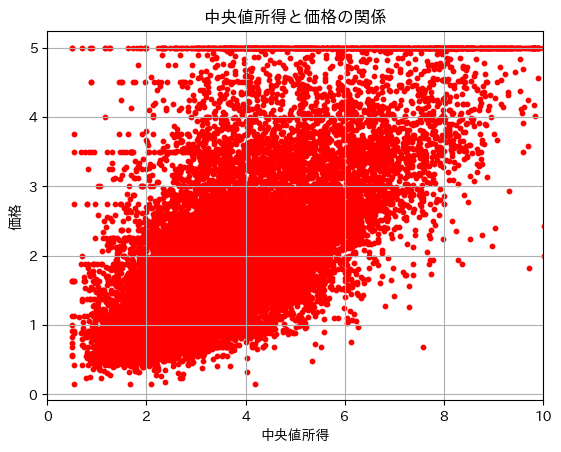

In [329]:
plt.scatter(x, yt, c='r', s=10)
plt.xlabel('中央値所得')
plt.ylabel('価格')
plt.title("中央値所得と価格の関係")
plt.xlim(0, 10)
plt.grid()
plt.show()


## モデル定義
機械学習・深層学習モデル：入力ベクトルに対して出力ベクトルを返す関数

### 変数定義

In [330]:
# 入力次元数
n_input = x.shape[1] # 説明変数の数（列数）

# 出力次元数
n_output = 1

print(f"入力次元数: {n_input}, 出力次元数: {n_output}")


入力次元数: 1, 出力次元数: 1


### 予測モデルのクラス定義

In [331]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_output) # 出力層

        # パラメータの初期値設定（しなければ乱数になる．）
        # nn.init.constant_(self.l1.weight, 1.0)
        # nn.init.constant_(self.l1.bias, 1.0)
    
    def forward(self, x):
        x1 = self.l1(x) # 線形単回帰
        return x1


### インスタンス生成

In [332]:
net = Net(n_input, n_output) # 1入力1出力の線形モデル


### モデル内のパラメータ値を確認
nn.Module内で定義されているnamed_parameters()を利用

In [333]:
for parameter in net.named_parameters():
    print('パラメータ名称:', parameter[0])
    print('パラメータ変数:', parameter[1].data)
    print()


パラメータ名称: l1.weight
パラメータ変数: tensor([[-0.7629]])

パラメータ名称: l1.bias
パラメータ変数: tensor([0.6548])



### parameters関数
「パラメータ変数」のみのリストが取得できる．最適化関数の初期化時に便利と聞いている．

In [334]:
for parameter in net.parameters():
    print(parameter, end='\n\n')


Parameter containing:
tensor([[-0.7629]], requires_grad=True)

Parameter containing:
tensor([0.6548], requires_grad=True)



### モデルの概要表示

In [335]:
print(net)


Net(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)


In [336]:
summary(net, (1, )) # summaryは「実際に一度ダミーデータを流して形を確認する」から，入力サイズが必要なんだ．


Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       2
Total params: 2
Trainable params: 2
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### 損失関数と最適化関数の定義

In [337]:
criterion = nn.MSELoss() # 損失関数：平均2乗誤差

lr = 0.01 # 学習率

# Stochastic Gradient Descent（確率的勾配降下法）
# loss.backward() によって勾配がリーフノードに記録され，optimizerは grad を見るだけで更新方向が分かる．
# net.parametersの順番は大事みたい．分けて書けば層ごとに学習率を変えることもできるとか…！
optimizer = optim.SGD(net.parameters(), lr=lr)


## 勾配降下法の実行
上と重複する部分があるけど許して．

### データのテンソル化および行列化

In [376]:
inputs = torch.tensor(x, dtype=torch.float32)
labels = torch.tensor(yt, dtype=torch.float32)

labels1 = labels.view((-1, 1)) # 損失計算用にlabelsを(N, 1)次元の行列に変換

print(inputs.shape)
print(labels1.shape)


torch.Size([20640, 1])
torch.Size([20640, 1])


### 初期化処理

In [377]:
lr = 0.0001 # 学習率

net = Net(n_input, n_output) # 予測モデルのインスタンス
criterion = nn.MSELoss() # 損失関数：平均2乗誤差
optimizer = optim.SGD(params=net.parameters(), lr=lr) # 最適化関数

num_epochs = 5000 # エポック数
history = np.zeros((0, 2)) # 損失記録用配列


### ループ処理

In [378]:
for epoch in range(num_epochs):
    optimizer.zero_grad() # 勾配初期化（最初に持ってこようね．）

    outputs = net(inputs) # 予測
    loss = criterion(outputs, labels1) # 損失
    loss.backward() # 勾配計算
    optimizer.step() # パラメータ更新

    if (epoch % 10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f"epoch: {epoch}, loss: {loss:.5f}")


epoch: 0, loss: 0.82815
epoch: 10, loss: 0.82057
epoch: 20, loss: 0.81355
epoch: 30, loss: 0.80706
epoch: 40, loss: 0.80105
epoch: 50, loss: 0.79549
epoch: 60, loss: 0.79035
epoch: 70, loss: 0.78559
epoch: 80, loss: 0.78118
epoch: 90, loss: 0.77710
epoch: 100, loss: 0.77333
epoch: 110, loss: 0.76984
epoch: 120, loss: 0.76660
epoch: 130, loss: 0.76361
epoch: 140, loss: 0.76084
epoch: 150, loss: 0.75827
epoch: 160, loss: 0.75590
epoch: 170, loss: 0.75370
epoch: 180, loss: 0.75167
epoch: 190, loss: 0.74978
epoch: 200, loss: 0.74804
epoch: 210, loss: 0.74642
epoch: 220, loss: 0.74493
epoch: 230, loss: 0.74354
epoch: 240, loss: 0.74226
epoch: 250, loss: 0.74107
epoch: 260, loss: 0.73997
epoch: 270, loss: 0.73895
epoch: 280, loss: 0.73801
epoch: 290, loss: 0.73713
epoch: 300, loss: 0.73632
epoch: 310, loss: 0.73557
epoch: 320, loss: 0.73487
epoch: 330, loss: 0.73422
epoch: 340, loss: 0.73362
epoch: 350, loss: 0.73307
epoch: 360, loss: 0.73255
epoch: 370, loss: 0.73207
epoch: 380, loss: 0.731

## 結果確認

In [379]:
print(f"損失初期値: {history[0, 1]:.5f}")
print(f"損失最終値: {history[-1, 1]:.5f}")


損失初期値: 0.82815
損失最終値: 0.71904


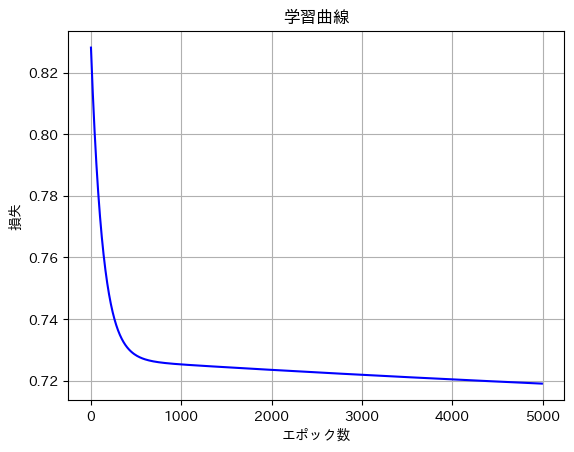

In [380]:
plt.plot(history[:, 0], history[:, 1], c='b')
plt.xlabel("エポック数")
plt.ylabel("損失")
plt.title('学習曲線')
plt.grid()
plt.show()


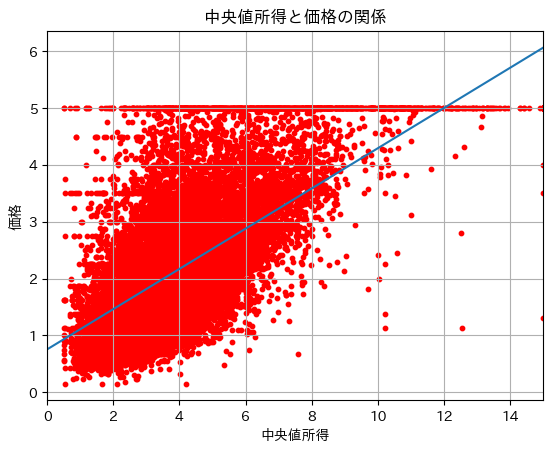

In [384]:
# 重みとバイアス取得
w = net.l1.weight.data.item()
b = net.l1.bias.data.item()

# 回帰直線
x_line = np.linspace(0, 15, 100)
y_line = w * x_line + b

plt.scatter(x, yt, c='r', s=10)
plt.plot(x_line, y_line)

plt.xlabel('中央値所得')
plt.ylabel('価格')
plt.title("中央値所得と価格の関係")
plt.xlim(0, 15)
plt.grid()
plt.show()


# 線形重回帰実習